In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from matplotlib import pyplot as plt
import os, corner
from datetime import datetime
import tensorflow_probability as tfp
tfd = tfp.distributions

class CustomCallback(tf.keras.callbacks.Callback):
    def __init__(self, PROGRESS_EPOCH=50):
        self.PROGRESS_EPOCH = PROGRESS_EPOCH
    def on_epoch_end(self, epoch, logs=None):
        if epoch % self.PROGRESS_EPOCH == 0:
            print(f"{datetime.now().strftime('%H:%M:%S')}, epoch {epoch}: ", end="")
            for key, val in logs.items():
                print(f"{key}: {val:.3f}", end= "\t")
            print()

tf.config.list_physical_devices('GPU')

2023-04-27 22:04:14.233089: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-04-27 22:04:16.654954: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2023-04-27 22:04:22.825188: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1956] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


[]

In [2]:
df = pd.read_csv('../camels_info/camels_parameters.csv')

out_dir = "../power_spectra/CO/20230313_no_std/"

def get_LH_files():
    fils = list(map(lambda fil: fil[:-4], \
               (filter(lambda fil: f"LH_" in fil, os.listdir(out_dir)))))
    sorter_1P_fils = lambda filname: int(filname.split('_')[-1].replace('n', '-'))
    return sorted(fils, key=sorter_1P_fils)

sim_names = get_LH_files()

if "LH_603" in sim_names:
    sim_names.remove("LH_603")
    
num_samples = len(sim_names)
print(num_samples)
non_nan_range = np.arange(24, 46)
all_curves = np.zeros((num_samples, 34, 22)) + np.nan
all_cosmologies = np.zeros((num_samples, 6)) + np.nan
for ind, fil in enumerate(sim_names):
    with np.load(out_dir + fil + ".npz", allow_pickle=True) as data:
        curves = data['curves'].item()
        redshifts = data['redshifts'].item()
        ks = data['ks'].item()
    all_curves[ind] = np.array(list(curves.values()))[:, non_nan_range]
    all_cosmologies[ind] = df.loc[df['Name'] == fil].values[0][1:-1]

999


In [3]:
train_split, val_split, test_split = int(0.85*num_samples), \
            int(0.10*num_samples) + 1, int(0.05*num_samples) + 1

print(train_split, val_split, test_split, train_split+val_split+test_split)

train_x, val_x, test_x = np.split(all_curves, [train_split, train_split+val_split])
train_y, val_y, test_y = np.split(all_cosmologies, [train_split, train_split+val_split])

print(train_x.shape, val_x.shape, test_x.shape)
print(train_y.shape, val_y.shape, test_y.shape)

kl_divergence_function = (lambda q, p, _: tfd.kl_divergence(q, p) /  # pylint: disable=g-long-lambda
                           tf.cast(train_split, dtype=tf.float32))

849 100 50 999
(849, 34, 22) (100, 34, 22) (50, 34, 22)
(849, 6) (100, 6) (50, 6)


In [4]:
# rough parameters, cannot use the best optuna due to different input shape
# use padding same
best_params = {'n_conv_layers': 3, 'n_dense_layers': 2, 'log2(n_conv_units_l0)': 4, 
               'n_conv_kernel_l0': 2, 'log2(n_conv_units_l1)': 2, 'n_conv_kernel_l1': 2, 
               'log2(n_conv_units_l2)': 2, 'n_conv_kernel_l2': 3, 'log2(n_dense_units_l0)': 6, 'log2(n_dense_units_l1)': 5}

def get_tf_model(input_shape):
    n_conv_layers = best_params['n_conv_layers']
    n_dense_layers = best_params['n_dense_layers']

    model = tf.keras.Sequential()
    model.add(tf.keras.layers.InputLayer(input_shape=input_shape))
    for i in range(n_conv_layers):
        num_hidden = 2 ** best_params[f'log2(n_conv_units_l{i})']
        kernel = best_params[f'n_conv_kernel_l{i}']
        model.add(tfp.layers.Convolution2DFlipout(num_hidden, kernel_size=(kernel, kernel),
                      kernel_divergence_fn=kl_divergence_function, activation=tf.nn.tanh, padding="same"))
        model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2)))

    model.add(tf.keras.layers.Flatten())

    for i in range(n_dense_layers):
        num_hidden = 2 ** best_params[f'log2(n_dense_units_l{i})']
        model.add(tfp.layers.DenseFlipout(num_hidden, activation=tf.nn.tanh,
              kernel_divergence_fn=kl_divergence_function))

    model.add(tf.keras.layers.Dense(tfp.layers.MultivariateNormalTriL.params_size(6)))
    model.add(tfp.layers.MultivariateNormalTriL(6))

    def negloglik(y_true, y_pred):
        return -tf.reduce_mean(y_pred.log_prob(y_true))

    optimizer=tf.keras.optimizers.Adadelta(learning_rate=0.2, rho=0.98)
    model.compile(optimizer, loss=negloglik, # tf.keras.losses.LogCosh(), # ['mse'], 
                  metrics=['mae', 'mse'], experimental_run_tf_function=False)
    model.summary()
    
    return model

In [5]:
inds, Zs = np.array(list(redshifts.keys())), np.array(list(redshifts.values()))

train_x_zless1, val_x_zless1, test_x_zless1 = train_x[:, Zs<1], val_x[:, Zs<1], test_x[:, Zs<1]
print(train_x_zless1.shape, val_x_zless1.shape, test_x_zless1.shape)

train_x_z_1_2, val_x_z_1_2, test_x_z_1_2 = train_x[:, np.logical_and(Zs>1, Zs<2)], \
                            val_x[:, np.logical_and(Zs>1, Zs<2)], test_x[:, np.logical_and(Zs>1, Zs<2)]
print(train_x_z_1_2.shape, val_x_z_1_2.shape, test_x_z_1_2.shape)

train_x_zover2, val_x_zover2, test_x_zover2 = train_x[:, Zs>2], val_x[:, Zs>2], test_x[:, Zs>2]
print(train_x_zover2.shape, val_x_zover2.shape, test_x_zover2.shape)

(849, 15, 22) (100, 15, 22) (50, 15, 22)
(849, 8, 22) (100, 8, 22) (50, 8, 22)
(849, 11, 22) (100, 11, 22) (50, 11, 22)


In [6]:
model_zless1, model_z_1_2, model_zover2, full_model = get_tf_model((15, 22, 1)), \
                        get_tf_model((8, 22, 1)), get_tf_model((11, 22, 1)), get_tf_model((34, 22, 1))

/global/homes/s/shubh/.conda/envs/simtim/lib/python3.9/site-packages/tensorflow_probability/python/layers/util.py:95: UserWarning: `layer.add_variable` is deprecated and will be removed in a future version. Please use the `layer.add_weight()` method instead.
  loc = add_variable_fn(
/global/homes/s/shubh/.conda/envs/simtim/lib/python3.9/site-packages/tensorflow_probability/python/layers/util.py:105: UserWarning: `layer.add_variable` is deprecated and will be removed in a future version. Please use the `layer.add_weight()` method instead.
  untransformed_scale = add_variable_fn(


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_flipout (Conv2DFlipo  (None, 15, 22, 16)       144       
 ut)                                                             
                                                                 
 max_pooling2d (MaxPooling2D  (None, 7, 11, 16)        0         
 )                                                               
                                                                 
 conv2d_flipout_1 (Conv2DFli  (None, 7, 11, 4)         516       
 pout)                                                           
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 3, 5, 4)          0         
 2D)                                                             
                                                                 
 conv2d_flipout_2 (Conv2DFli  (None, 3, 5, 4)          2

In [11]:
model_zless1.fit(train_x_zless1, train_y, epochs=2000, validation_data=(val_x_zless1, val_y), verbose=0, callbacks=[CustomCallback(200)])

22:20:37, epoch 0: loss: 3.877	mae: 0.589	mse: 0.876	val_loss: 3.831	val_mae: 0.579	val_mse: 0.801	
22:20:55, epoch 100: loss: 3.627	mae: 0.584	mse: 0.858	val_loss: 3.764	val_mae: 0.575	val_mse: 0.749	
22:21:13, epoch 200: loss: 3.442	mae: 0.571	mse: 0.813	val_loss: 3.475	val_mae: 0.563	val_mse: 0.805	
22:21:32, epoch 300: loss: 3.315	mae: 0.583	mse: 0.863	val_loss: 3.500	val_mae: 0.540	val_mse: 0.693	
22:21:49, epoch 400: loss: 3.249	mae: 0.566	mse: 0.774	val_loss: 3.209	val_mae: 0.564	val_mse: 0.777	
22:22:07, epoch 500: loss: 3.131	mae: 0.576	mse: 0.839	val_loss: 3.397	val_mae: 0.549	val_mse: 0.730	
22:22:26, epoch 600: loss: 3.062	mae: 0.575	mse: 0.828	val_loss: 3.048	val_mae: 0.585	val_mse: 0.906	
22:22:44, epoch 700: loss: 3.012	mae: 0.577	mse: 0.842	val_loss: 2.975	val_mae: 0.554	val_mse: 0.752	
22:23:01, epoch 800: loss: 2.905	mae: 0.579	mse: 0.842	val_loss: 3.034	val_mae: 0.587	val_mse: 0.912	
22:23:19, epoch 900: loss: 2.900	mae: 0.579	mse: 0.818	val_loss: 3.076	val_mae: 0.54

In [12]:
model_z_1_2.fit(train_x_z_1_2, train_y, epochs=2000, validation_data=(val_x_z_1_2, val_y), verbose=0, callbacks=[CustomCallback(200)])

22:23:40, epoch 0: loss: 19.182	mae: 1.115	mse: 2.056	val_loss: 16.627	val_mae: 1.144	val_mse: 2.158	
22:24:11, epoch 200: loss: 9.689	mae: 0.594	mse: 0.825	val_loss: 9.562	val_mae: 0.612	val_mse: 0.879	
22:24:42, epoch 400: loss: 7.863	mae: 0.599	mse: 0.845	val_loss: 7.773	val_mae: 0.584	val_mse: 0.717	
22:25:13, epoch 600: loss: 6.412	mae: 0.608	mse: 0.867	val_loss: 6.296	val_mae: 0.570	val_mse: 0.745	
22:25:45, epoch 800: loss: 5.234	mae: 0.595	mse: 0.829	val_loss: 5.114	val_mae: 0.613	val_mse: 0.855	
22:26:16, epoch 1000: loss: 4.345	mae: 0.603	mse: 0.858	val_loss: 4.206	val_mae: 0.613	val_mse: 0.881	
22:26:47, epoch 1200: loss: 3.966	mae: 0.601	mse: 0.854	val_loss: 3.864	val_mae: 0.597	val_mse: 0.771	
22:27:19, epoch 1400: loss: 3.755	mae: 0.594	mse: 0.839	val_loss: 3.668	val_mae: 0.615	val_mse: 0.874	
22:27:52, epoch 1600: loss: 3.631	mae: 0.607	mse: 0.877	val_loss: 3.504	val_mae: 0.582	val_mse: 0.817	
22:28:24, epoch 1800: loss: 3.529	mae: 0.606	mse: 0.857	val_loss: 3.404	val_ma

In [13]:
model_zover2.fit(train_x_zover2, train_y, epochs=2000, validation_data=(val_x_zover2, val_y), verbose=0, callbacks=[CustomCallback(200)])

22:29:00, epoch 0: loss: 22.918	mae: 1.130	mse: 2.080	val_loss: 18.687	val_mae: 1.109	val_mse: 1.972	
22:29:35, epoch 200: loss: 9.823	mae: 0.598	mse: 0.847	val_loss: 9.678	val_mae: 0.541	val_mse: 0.707	
22:30:08, epoch 400: loss: 8.177	mae: 0.598	mse: 0.852	val_loss: 8.021	val_mae: 0.583	val_mse: 0.796	
22:30:42, epoch 600: loss: 6.604	mae: 0.595	mse: 0.842	val_loss: 6.471	val_mae: 0.548	val_mse: 0.656	
22:31:15, epoch 800: loss: 5.300	mae: 0.581	mse: 0.820	val_loss: 5.162	val_mae: 0.565	val_mse: 0.743	
22:31:48, epoch 1000: loss: 4.606	mae: 0.586	mse: 0.839	val_loss: 4.471	val_mae: 0.576	val_mse: 0.798	
22:32:22, epoch 1200: loss: 4.207	mae: 0.587	mse: 0.844	val_loss: 4.047	val_mae: 0.600	val_mse: 0.851	
22:32:55, epoch 1400: loss: 3.910	mae: 0.582	mse: 0.838	val_loss: 3.841	val_mae: 0.552	val_mse: 0.690	
22:33:27, epoch 1600: loss: 3.722	mae: 0.580	mse: 0.804	val_loss: 3.704	val_mae: 0.560	val_mse: 0.746	
22:34:00, epoch 1800: loss: 3.591	mae: 0.594	mse: 0.847	val_loss: 3.531	val_ma

In [14]:
full_model.fit(train_x, train_y, epochs=2000, validation_data=(val_x, val_y), verbose=0, callbacks=[CustomCallback(200)])

22:34:36, epoch 0: loss: 25.795	mae: 1.209	mse: 2.326	val_loss: 22.547	val_mae: 1.060	val_mse: 1.861	
22:35:19, epoch 200: loss: 13.153	mae: 0.599	mse: 0.863	val_loss: 13.144	val_mae: 0.583	val_mse: 0.838	
22:36:04, epoch 400: loss: 10.210	mae: 0.581	mse: 0.857	val_loss: 10.384	val_mae: 0.568	val_mse: 0.806	
22:36:50, epoch 600: loss: 8.141	mae: 0.582	mse: 0.851	val_loss: 8.298	val_mae: 0.563	val_mse: 0.725	
22:37:36, epoch 800: loss: 6.816	mae: 0.571	mse: 0.828	val_loss: 6.751	val_mae: 0.553	val_mse: 0.736	
22:38:25, epoch 1000: loss: 5.894	mae: 0.578	mse: 0.849	val_loss: 5.962	val_mae: 0.573	val_mse: 0.798	
22:39:14, epoch 1200: loss: 5.185	mae: 0.570	mse: 0.831	val_loss: 5.412	val_mae: 0.546	val_mse: 0.743	
22:40:01, epoch 1400: loss: 4.747	mae: 0.564	mse: 0.800	val_loss: 4.786	val_mae: 0.522	val_mse: 0.664	
22:40:48, epoch 1600: loss: 4.389	mae: 0.562	mse: 0.798	val_loss: 4.255	val_mae: 0.563	val_mse: 0.730	
22:41:37, epoch 1800: loss: 4.032	mae: 0.574	mse: 0.848	val_loss: 4.349	va

[0.2454 0.6162]
0
200
400
600
800
0
200
400
600
800
0
200
400
600
800
0
200
400
600
800


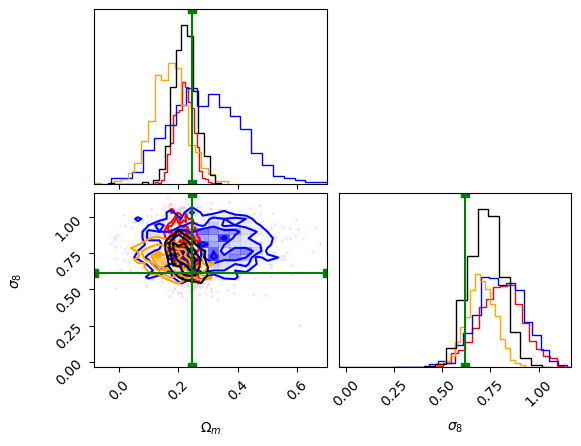

In [17]:
index = np.random.randint(len(test_y))
print(test_y[index, :2])

n_pred = 1000
fig = plt.figure()
for ind, (model, text_x, color) in enumerate(zip([model_zless1, model_z_1_2, model_zover2, full_model], \
                [test_x_zless1, test_x_z_1_2, test_x_zover2, test_x], ["red", "blue", "orange", "black"])):
    predictions = np.empty((n_pred, 2))
    for i in range(n_pred):
        if i % 200 == 0:
            print(i)
        predictions[i] = model.predict(text_x[index][None, :, :], verbose=0)[:, :2]
    corner.corner(predictions, labels=[r"$\Omega_m$", r"$\sigma_8$"], fig=fig, color=color)
    
corner.overplot_lines(fig, test_y[index, :2], marker="s", color="green")

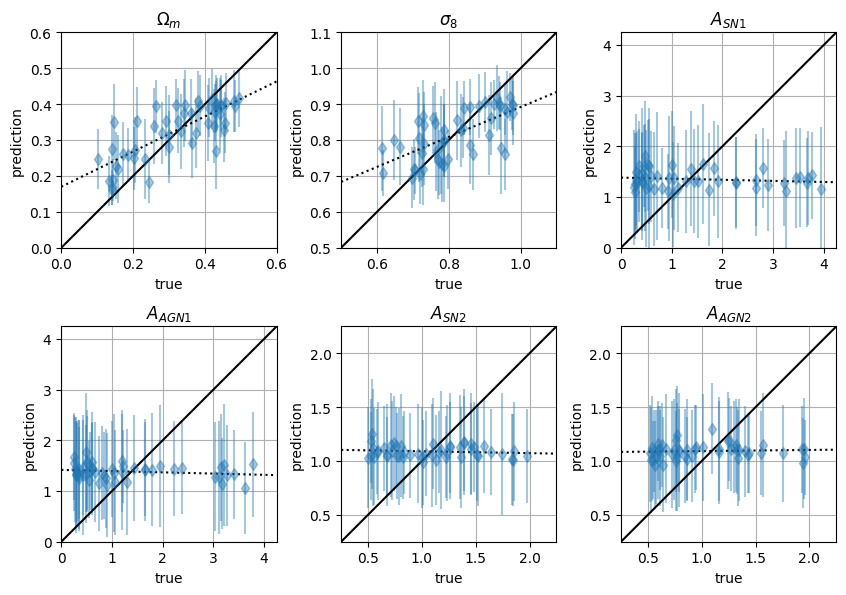

In [22]:
model = model_zover2

plot_x, plot_y = test_x_zover2, test_y

n_pred = 50
predictions = np.empty((n_pred, *plot_y.shape))
for i in range(n_pred):
    predictions[i] = model.predict(plot_x, verbose=0)
predictions_best = np.nanmean(predictions, axis=0)
predictions_std = np.nanstd(predictions, axis=0)

upp_lims = [0.6, 1.1,4.25,4.25,2.25, 2.25]
low_lims = [0, 0.5, 0, 0, 0.25, 0.25]
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(10, 7))
fig.subplots_adjust(wspace=0.3, hspace=0.2)
labels = [r"$\Omega_m$", r"$\sigma_8$", r"$A_{SN1}$", r"$A_{AGN1}$", r"$A_{SN2}$", r"$A_{AGN2}$"]
for ind, (label, ax, low_lim, upp_lim) in enumerate(zip(labels, axs.ravel(), low_lims, upp_lims)):
    p = np.poly1d(np.polyfit(plot_y[:, ind], predictions_best[:, ind], 1))
    ax.errorbar(plot_y[:, ind], predictions_best[:, ind],  predictions_std[:, ind], marker="d", ls='none', alpha=0.4)
    ax.set_xlabel("true")
    ax.set_ylabel("prediction")
    ax.plot([low_lim, upp_lim], [low_lim, upp_lim], color="black")
    ax.plot([low_lim, upp_lim], [p(low_lim), p(upp_lim)], color="black", ls=":")
    ax.set_xlim([low_lim, upp_lim])
    ax.set_ylim([low_lim, upp_lim])
    ax.set_aspect('equal', adjustable='box')
    ax.set_title(label)
    ax.grid()
plt.show()
plt.close()